In [1]:
import duckdb
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

conn = duckdb.connect('../data/database/weather_daily.duckdb')

df = conn.execute("""
SELECT *
FROM raw.weather_daily_historical
""").df()

print("Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nData types:\n", df.dtypes)
df.head()

Shape: (7308, 14)

Columns:
 Index(['date', 'city', 'weathercode', 'temperature_2m_max',
       'temperature_2m_min', 'apparent_temperature_max',
       'apparent_temperature_min', 'precipitation_sum', 'precipitation_hours',
       'rain_sum', 'snowfall_sum', 'windspeed_10m_max', 'windgusts_10m_max',
       'winddirection_10m_dominant'],
      dtype='str')

Data types:
 date                          datetime64[us]
city                                     str
weathercode                          float64
temperature_2m_max                   float64
temperature_2m_min                   float64
apparent_temperature_max             float64
apparent_temperature_min             float64
precipitation_sum                    float64
precipitation_hours                  float64
rain_sum                             float64
snowfall_sum                         float64
windspeed_10m_max                    float64
windgusts_10m_max                    float64
winddirection_10m_dominant           float

,date,city,weathercode,temperature_2m_max,temperature_2m_min,apparent_temperature_max,apparent_temperature_min,precipitation_sum,precipitation_hours,rain_sum,snowfall_sum,windspeed_10m_max,windgusts_10m_max,winddirection_10m_dominant
0,2021-04-17 20:00:00,Ganja,3.0,23.65,12.10,24.438683,10.742480,0.0,0.0,0.0,0.0,10.002560,19.800000,262.53488
1,2021-04-18 20:00:00,Ganja,3.0,24.85,16.85,25.520826,15.731947,0.0,0.0,0.0,0.0,13.979871,30.599998,282.76645
2,2021-04-19 20:00:00,Ganja,3.0,28.10,15.75,28.567589,14.604889,0.0,0.0,0.0,0.0,12.722830,25.560000,218.82477
3,2021-04-20 20:00:00,Ganja,3.0,29.55,16.00,30.550972,14.980011,0.0,0.0,0.0,0.0,10.390226,29.519999,229.16669
4,2021-04-21 20:00:00,Ganja,3.0,22.05,13.80,21.636019,12.903557,0.0,0.0,0.0,0.0,19.191748,35.640000,124.28695


In [2]:
missing_percent = df.isnull().mean() * 100
missing_percent.sort_values(ascending=False)

df.groupby("city").apply(lambda x: x.isnull().mean() * 100)


,date,weathercode,temperature_2m_max,temperature_2m_min,apparent_temperature_max,apparent_temperature_min,precipitation_sum,precipitation_hours,rain_sum,snowfall_sum,windspeed_10m_max,windgusts_10m_max,winddirection_10m_dominant
city,,,,,,,,,,,,,
Baku,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Ganja,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Nakhchivan,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Shusha,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
print(df.describe())

                      date  weathercode  temperature_2m_max  \
count                 7308  7308.000000         7308.000000   
mean   2023-10-17 20:00:00    21.970307           18.451535   
min    2021-04-17 20:00:00     0.000000           -7.803000   
25%    2022-07-17 20:00:00     2.000000           10.050000   
50%    2023-10-17 20:00:00     3.000000           17.973500   
75%    2025-01-16 20:00:00    51.000000           26.647751   
max    2026-04-17 20:00:00    75.000000           42.350000   
std                    NaN    26.913108           10.278012   

       temperature_2m_min  apparent_temperature_max  apparent_temperature_min  \
count         7308.000000               7308.000000               7308.000000   
mean             9.616902                 16.678792                  7.685663   
min            -14.803000                -12.527184                -19.868164   
25%              2.749250                  7.081387                 -0.503247   
50%              9.573500  

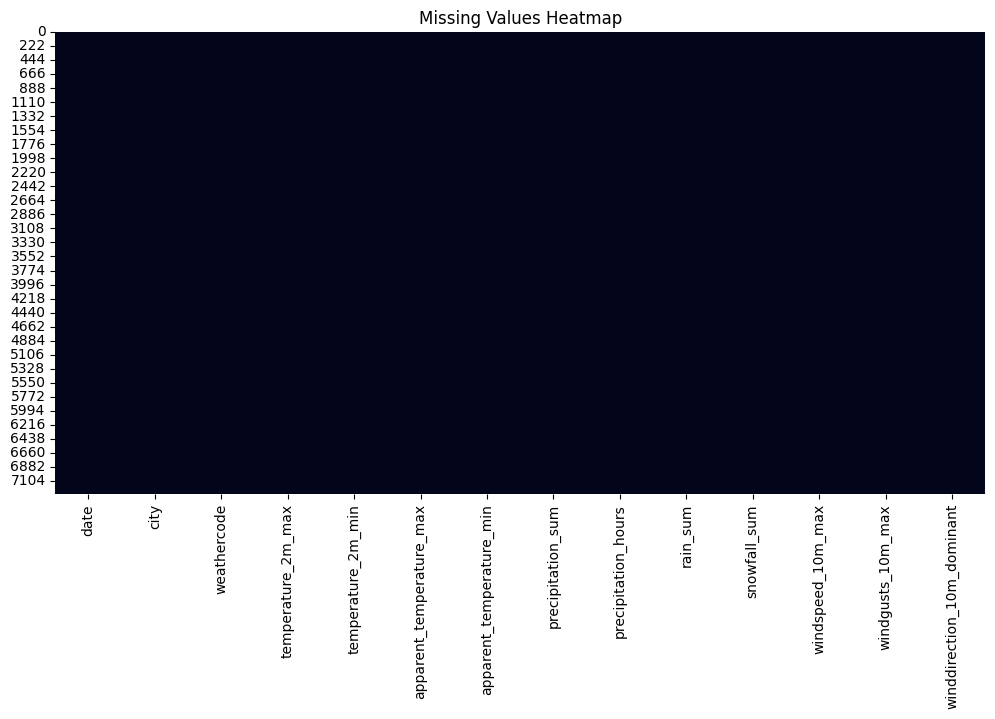

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

In [5]:
col = "temperature_2m_max"

Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

print("Outliers count:", len(outliers))
outliers.head()

Outliers count: 0


,date,city,weathercode,temperature_2m_max,temperature_2m_min,apparent_temperature_max,apparent_temperature_min,precipitation_sum,precipitation_hours,rain_sum,snowfall_sum,windspeed_10m_max,windgusts_10m_max,winddirection_10m_dominant


In [6]:
def detect_outliers_iqr(df, column):
    results = {}

    for city in df["city"].unique():
        city_df = df[df["city"] == city]

        Q1 = city_df[column].quantile(0.25)
        Q3 = city_df[column].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outliers = city_df[(city_df[column] < lower) | (city_df[column] > upper)]

        results[city] = len(outliers)

    return results


detect_outliers_iqr(df, "temperature_2m_max")

{'Ganja': 0, 'Nakhchivan': 0, 'Baku': 0, 'Shusha': 0}

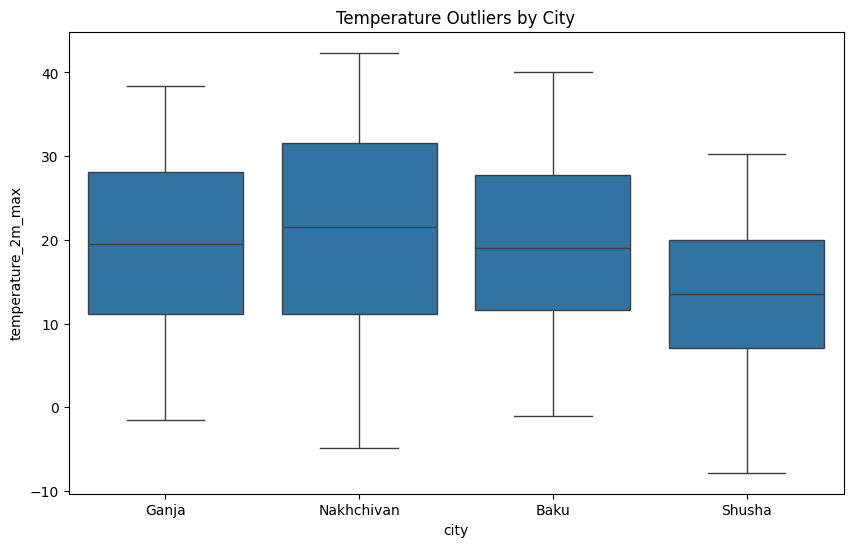

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="city", y="temperature_2m_max")
plt.title("Temperature Outliers by City")
plt.show()

In [8]:
conn.execute("""
WITH date_series AS (
    SELECT DISTINCT city, DATE(date) as date
    FROM raw.weather_daily_historical
),

expected_dates AS (
    SELECT 
        city,
        DATE(UNNEST(generate_series(
            MIN(date),
            MAX(date),
            INTERVAL 1 DAY
        ))) AS expected_date
    FROM raw.weather_daily_historical
    GROUP BY city
)

SELECT *
FROM expected_dates e
LEFT JOIN date_series d
ON e.city = d.city AND e.expected_date = d.date
WHERE d.date IS NULL;
""").df()

,city,expected_date,city_1,date


## Temporal Gap Check

This query compares the **expected date range** (continuous daily dates) with the **actual dates** in the dataset.

- `expected_date` → dates that should exist  
- `date` → dates that actually exist in the data  
- `NULL` values → indicate missing days  

Result:
- The output is an empty DataFrame, meaning **no missing dates were found**.

Conclusion:
The dataset contains a **complete and continuous time series** for all cities.

In [9]:
conn.execute("""
SELECT 
    h.city,
    DATE(h.date) as date,
    h.temperature_2m_max as hist_temp,
    f.temperature_2m_max as forecast_temp
FROM raw.weather_daily_historical h
JOIN raw.weather_daily_forecast f
ON h.city = f.city 
AND DATE(h.date) = DATE(f.date)
""").df()

,city,date,hist_temp,forecast_temp


## Consistency Check (Historical vs Forecast)

We checked for overlapping dates between historical and forecast datasets by joining them on `city` and `date`.

Result:
- The query returned an empty DataFrame, meaning no overlapping dates were found.

Conclusion:
There is no overlap between historical and forecast data.  
This is expected, as historical data ends before the forecast period begins.  
Therefore, the datasets are consistent and do not contain conflicting values.

Since no overlapping dates exist between historical and forecast datasets, no direct value comparison is required.

In [15]:
df = conn.execute("""
SELECT city, date, temperature_2m_max
FROM raw.weather_daily_historical
ORDER BY city, date
""").df()

# eyni dəyərlərin ardıcıllığını tapmaq
df["same_as_prev"] = df.groupby("city")["temperature_2m_max"].diff() == 0

df[df["same_as_prev"] == True].head(20)

,city,date,temperature_2m_max,same_as_prev
8,Baku,2021-04-25 20:00:00,21.10,True
20,Baku,2021-05-07 20:00:00,19.80,True
50,Baku,2021-06-06 20:00:00,23.50,True
125,Baku,2021-08-20 20:00:00,36.10,True
172,Baku,2021-10-06 20:00:00,15.70,True
565,Baku,2022-11-03 20:00:00,17.80,True
623,Baku,2022-12-31 20:00:00,10.35,True
629,Baku,2023-01-06 20:00:00,9.20,True
988,Baku,2023-12-31 20:00:00,12.40,True
1020,Baku,2024-02-01 20:00:00,8.20,True


## Constant Value Check (Sensor Artefacts)

We checked whether temperature values remain constant across consecutive days within each city.

Method:
- Computed day-to-day differences using `diff()`
- Flagged cases where the difference equals zero

Result:
- Some isolated repeated values were observed
- No long consecutive sequences of identical values were found

Conclusion:
The dataset does not show signs of sensor freezing or data artefacts.

In [12]:
df["temp_diff"] = df.groupby("city")["temperature_2m_max"].diff().abs()

df[df["temp_diff"] > 10]

,city,date,temperature_2m_max,same_as_prev,temp_diff
228,Baku,2021-12-01 20:00:00,9.950,False,14.700000
688,Baku,2023-03-06 20:00:00,7.950,False,11.100000
1431,Baku,2025-03-18 20:00:00,14.250,False,16.050000
1471,Baku,2025-04-27 20:00:00,13.500,False,11.150000
1768,Baku,2026-02-18 20:00:00,22.700,False,12.200000
1769,Baku,2026-02-19 20:00:00,10.700,False,12.000000
1928,Ganja,2021-07-27 20:00:00,25.300,False,10.750000
2187,Ganja,2022-04-12 20:00:00,14.200,False,10.300000
2781,Ganja,2023-11-27 20:00:00,9.300,False,10.200000
3258,Ganja,2025-03-18 20:00:00,16.450,False,11.300000


## Sudden Jump (Outlier) Detection

We calculated day-to-day temperature differences using absolute values of consecutive changes per city.

Method:
- Computed `diff()` to capture daily changes
- Applied absolute value to measure magnitude
- Filtered values greater than 10°C

Result:
- A small number of large temperature changes were detected
- These events are scattered across time and cities

Conclusion:
The detected variations are likely due to natural weather fluctuations rather than data errors.

In [1]:
import duckdb
import pandas as pd
import os
import sys

sys.path.append(os.path.abspath("../src"))

from database import get_connection
from cleaning import clean_raw_to_staging

In [2]:
db_path = "../data/database/weather_daily.duckdb"
conn = get_connection(db_path)

In [3]:
conn.execute("""
SELECT 
    'historical' AS table_name,
    COUNT(*) AS rows
FROM raw.weather_daily_historical

UNION ALL

SELECT 
    'forecast',
    COUNT(*)
FROM raw.weather_daily_forecast;
""").df()

,table_name,rows
0,historical,7308
1,forecast,28


In [4]:
clean_raw_to_staging(conn)


══════════════════════════════════════════════════
  Processing raw.weather_daily_historical …
  Rows loaded : 7,308
  Handling missing values …
  Nulls before: 0  →  after: 0
  Flagging outliers (IQR, threshold=1.5) …
  Total outlier flags: 4,155  across 12 columns
  Validating date continuity …

─────────────────────────────────────────────
  City            : Ganja
  Date range      : 2021-04-17 → 2026-04-17
  Expected days   : 1827
  Actual days     : 1827
  Missing days    : 0
─────────────────────────────────────────────

─────────────────────────────────────────────
  City            : Nakhchivan
  Date range      : 2021-04-17 → 2026-04-17
  Expected days   : 1827
  Actual days     : 1827
  Missing days    : 0
─────────────────────────────────────────────

─────────────────────────────────────────────
  City            : Baku
  Date range      : 2021-04-17 → 2026-04-17
  Expected days   : 1827
  Actual days     : 1827
  Missing days    : 0
──────────────────────────────────────

In [5]:
conn.execute("SHOW TABLES FROM staging;").df()

,name
0,weather_daily_forecast
1,weather_daily_historical


In [6]:
conn.execute("""
SELECT * 
FROM staging.weather_daily_historical
LIMIT 5;
""").df()

,date,city,weathercode,temperature_2m_max,temperature_2m_min,apparent_temperature_max,apparent_temperature_min,precipitation_sum,precipitation_hours,rain_sum,...,temperature_2m_min_outlier,apparent_temperature_max_outlier,apparent_temperature_min_outlier,precipitation_sum_outlier,precipitation_hours_outlier,rain_sum_outlier,snowfall_sum_outlier,windspeed_10m_max_outlier,windgusts_10m_max_outlier,winddirection_10m_dominant_outlier
0,2021-04-17 20:00:00,Ganja,3.0,23.65,12.10,24.438683,10.742480,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False
1,2021-04-18 20:00:00,Ganja,3.0,24.85,16.85,25.520826,15.731947,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False
2,2021-04-19 20:00:00,Ganja,3.0,28.10,15.75,28.567589,14.604889,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False
3,2021-04-20 20:00:00,Ganja,3.0,29.55,16.00,30.550972,14.980011,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False
4,2021-04-21 20:00:00,Ganja,3.0,22.05,13.80,21.636019,12.903557,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False


In [7]:
conn.execute("""
SELECT * 
FROM staging.weather_daily_forecast
LIMIT 5;
""").df()

,date,city,weathercode,temperature_2m_max,temperature_2m_min,apparent_temperature_max,apparent_temperature_min,precipitation_sum,precipitation_hours,rain_sum,...,temperature_2m_min_outlier,apparent_temperature_max_outlier,apparent_temperature_min_outlier,precipitation_sum_outlier,precipitation_hours_outlier,rain_sum_outlier,snowfall_sum_outlier,windspeed_10m_max_outlier,windgusts_10m_max_outlier,winddirection_10m_dominant_outlier
0,2026-04-20 20:00:00,Baku,80.0,11.363,9.113000,8.242756,6.040869,7.5,12.0,7.099999,...,False,False,False,False,False,True,False,False,False,False
1,2026-04-21 20:00:00,Baku,3.0,16.163,8.962999,14.989140,7.764010,0.0,0.0,0.000000,...,False,False,False,False,False,False,False,False,False,False
2,2026-04-22 20:00:00,Baku,3.0,15.063,10.313000,13.524242,6.583144,0.0,0.0,0.000000,...,False,False,False,False,False,False,False,False,False,False
3,2026-04-23 20:00:00,Baku,3.0,16.813,9.912999,17.315119,6.416477,0.0,0.0,0.000000,...,False,False,False,False,False,False,False,False,False,False
4,2026-04-24 20:00:00,Baku,3.0,14.513,9.947500,13.053892,5.641928,0.0,0.0,0.000000,...,False,False,False,False,False,False,False,False,False,False


In [8]:
conn.execute("""
SELECT 
    COUNT(*) as total_rows,
    SUM(CASE WHEN temperature_2m_max IS NULL THEN 1 ELSE 0 END) AS null_temp
FROM staging.weather_daily_historical;
""").df()

,total_rows,null_temp
0,7308,0.0


In [9]:
conn.execute("""
SELECT 
    * from staging.weather_daily_historical;
""").df()

,date,city,weathercode,temperature_2m_max,temperature_2m_min,apparent_temperature_max,apparent_temperature_min,precipitation_sum,precipitation_hours,rain_sum,...,temperature_2m_min_outlier,apparent_temperature_max_outlier,apparent_temperature_min_outlier,precipitation_sum_outlier,precipitation_hours_outlier,rain_sum_outlier,snowfall_sum_outlier,windspeed_10m_max_outlier,windgusts_10m_max_outlier,winddirection_10m_dominant_outlier
0,2021-04-17 20:00:00,Ganja,3.0,23.650,12.100,24.438683,10.742480,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False
1,2021-04-18 20:00:00,Ganja,3.0,24.850,16.850,25.520826,15.731947,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False
2,2021-04-19 20:00:00,Ganja,3.0,28.100,15.750,28.567589,14.604889,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False
3,2021-04-20 20:00:00,Ganja,3.0,29.550,16.000,30.550972,14.980011,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False
4,2021-04-21 20:00:00,Ganja,3.0,22.050,13.800,21.636019,12.903557,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7303,2026-04-13 20:00:00,Shusha,75.0,6.097,-1.153,3.153990,-4.598348,8.7,12.0,6.5,...,False,False,False,True,True,True,True,False,False,False
7304,2026-04-14 20:00:00,Shusha,51.0,7.697,-1.603,4.332549,-4.514069,0.8,5.0,0.8,...,False,False,False,False,False,False,False,False,False,False
7305,2026-04-15 20:00:00,Shusha,51.0,8.697,-0.153,6.354669,-3.464891,0.4,4.0,0.4,...,False,False,False,False,False,False,False,False,False,False
7306,2026-04-16 20:00:00,Shusha,3.0,9.347,-0.003,7.191963,-3.064946,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False


In [14]:
sys.path.append(os.path.abspath("../src"))

from database import get_connection
from features import (
    create_staging_table,
    create_base_features_historical,
    create_forecast_features
)

In [15]:
create_staging_table(conn)

In [16]:
conn.execute("SHOW TABLES FROM staging;").df()

,name
0,weather_daily_forecast
1,weather_daily_historical


In [19]:
conn.execute("SHOW TABLES FROM analytics;").df()

,name
0,weather_features_historical


In [24]:
create_base_features_historical(conn)
create_forecast_features(conn)

In [25]:
conn.execute("SHOW TABLES FROM analytics;").df()

,name
0,weather_features_forecast
1,weather_features_historical


In [18]:
conn.execute("""
SELECT 
    city,
    date,
    temp_mean,
    temp_7d_avg,
    HDD,
    CDD
FROM analytics.weather_features_historical
LIMIT 10;
""").df()

,city,date,temp_mean,temp_7d_avg,HDD,CDD
0,Nakhchivan,2021-04-17 20:00:00,19.000,19.000000,0.0,1.000
1,Nakhchivan,2021-04-18 20:00:00,20.375,19.687500,0.0,2.375
2,Nakhchivan,2021-04-19 20:00:00,21.575,20.316667,0.0,3.575
3,Nakhchivan,2021-04-20 20:00:00,22.600,20.887500,0.0,4.600
4,Nakhchivan,2021-04-21 20:00:00,25.075,21.725000,0.0,7.075
5,Nakhchivan,2021-04-22 20:00:00,20.575,21.533333,0.0,2.575
6,Nakhchivan,2021-04-23 20:00:00,19.800,21.285714,0.0,1.800
7,Nakhchivan,2021-04-24 20:00:00,21.725,21.675000,0.0,3.725
8,Nakhchivan,2021-04-25 20:00:00,21.050,21.771429,0.0,3.050
9,Nakhchivan,2021-04-26 20:00:00,22.625,21.921429,0.0,4.625


In [21]:
create_forecast_features(conn)

In [23]:
conn.execute("""
SELECT 
    *
FROM analytics.weather_features_forecast
LIMIT 10;
""").df()

,date,city,weathercode,temperature_2m_max,temperature_2m_min,apparent_temperature_max,apparent_temperature_min,precipitation_sum,precipitation_hours,rain_sum,snowfall_sum,windspeed_10m_max,windgusts_10m_max,winddirection_10m_dominant,temp_mean,temp_range,month,quarter,day_of_year,season
0,2026-04-20 20:00:00,Baku,80.0,11.363000,9.113000,8.242756,6.040869,7.5,12.0,7.099999,0.0,27.059933,49.680000,357.52774,10.238000,2.250000,4,2,110,spring
1,2026-04-21 20:00:00,Baku,3.0,16.163000,8.962999,14.989140,7.764010,0.0,0.0,0.000000,0.0,22.881956,39.600000,178.35300,12.563000,7.200001,4,2,111,spring
2,2026-04-22 20:00:00,Baku,3.0,15.063000,10.313000,13.524242,6.583144,0.0,0.0,0.000000,0.0,23.319553,39.960000,332.20310,12.688000,4.750000,4,2,112,spring
3,2026-04-23 20:00:00,Baku,3.0,16.813000,9.912999,17.315119,6.416477,0.0,0.0,0.000000,0.0,23.023119,39.239998,352.49908,13.362999,6.900001,4,2,113,spring
4,2026-04-24 20:00:00,Baku,3.0,14.513000,9.947500,13.053892,5.641928,0.0,0.0,0.000000,0.0,34.322937,64.439995,346.50430,12.230250,4.565500,4,2,114,spring
5,2026-04-25 20:00:00,Baku,3.0,18.197500,8.947500,16.001568,6.831017,0.0,0.0,0.000000,0.0,22.910260,38.519997,224.82254,13.572500,9.250000,4,2,115,spring
6,2026-04-26 20:00:00,Baku,61.0,16.847500,10.747499,11.063116,6.607490,0.3,3.0,0.300000,0.0,47.684715,86.039990,356.65730,13.797500,6.100001,4,2,116,spring
7,2026-04-20 20:00:00,Ganja,63.0,11.015500,8.565499,10.091321,7.277757,15.8,16.0,15.200001,0.0,10.080000,18.359999,343.67307,9.790499,2.450001,4,2,110,spring
8,2026-04-21 20:00:00,Ganja,3.0,18.915500,7.065500,18.103548,4.816320,0.0,0.0,0.000000,0.0,9.693295,18.359999,167.36665,12.990500,11.850000,4,2,111,spring
9,2026-04-22 20:00:00,Ganja,3.0,21.765501,9.365500,21.215542,7.411629,0.0,0.0,0.000000,0.0,21.933426,41.760002,122.61924,15.565500,12.400002,4,2,112,spring
